**Classification**

# Imports

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_val_predict
from utils.logreg import simu_logreg
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)


plt.rc("font", size=14)
plt.rc("axes", labelsize=14, titlesize=14)
plt.rc("legend", fontsize=14)
plt.rc("xtick", labelsize=10)
plt.rc("ytick", labelsize=10)

# Sigmoid

In [2]:
def sigmoid_first(t):
    """Implement the sigmoid function."""
    return  1 / (1 + np.exp(-t))

In [3]:
def sigmoid(t):
    """Evaluate the Sigmoid function at t (overflow-proof)"""
    idx = t > 0
    out = np.empty(t.size)
    out[idx] = 1 / (1.0 + np.exp(-t[idx]))
    exp_t = np.exp(t[~idx])
    out[~idx] = exp_t / (1.0 + exp_t)
    return out

- we can also use the sigmoid function from scipy [scipy.special.expit](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.expit.html#scipy.special.expit) which is numerically more stable than the naive implementation above

- Pytorch also has a built-in sigmoid function [torch.sigmoid](https://pytorch.org/docs/stable/generated/torch.sigmoid.html#torch.sigmoid) that we can use

- this is important for the softmax function as well, which we will see later in the course

- https://en.wikipedia.org/wiki/LogSumExp

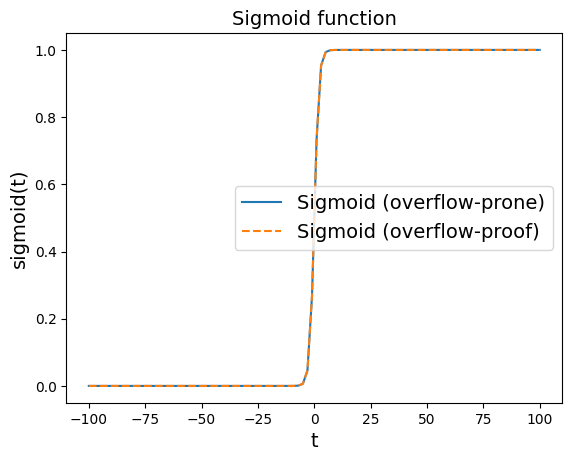

In [4]:
ts = np.linspace(-(10**2), 10**2, 100)
fig, ax = plt.subplots()
ax.plot(ts, sigmoid_first(ts), label="Sigmoid (overflow-prone)")
ax.plot(ts, sigmoid(ts), label="Sigmoid (overflow-proof)", linestyle="dashed")
ax.set_xlabel("t")
ax.set_ylabel("sigmoid(t)")
plt.title("Sigmoid function")
plt.legend()
plt.show()

# A First Example

In [5]:
# Simulate a logistic regression model with 2 features and 500 samples
n_samples = 500
w0 = np.array([-3.0, 3.0])
X, y = simu_logreg(w0, n_samples=n_samples, corr=0.4)

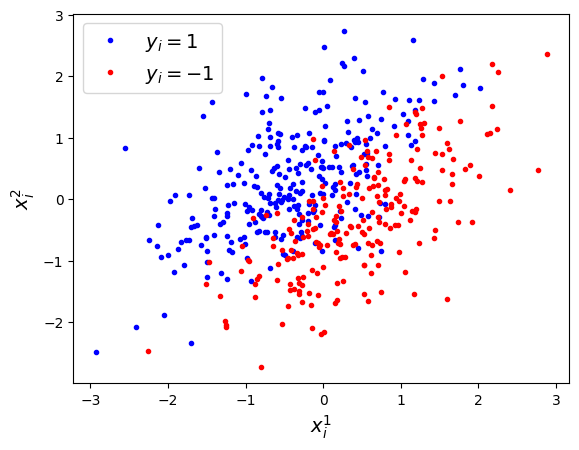

In [6]:
fig, ax = plt.subplots()
ax.plot(*X[y == 1].T, ".b", label=r"$y_i=1$")
ax.plot(*X[y == -1].T, ".r", label=r"$y_i=-1$")
ax.set_xlabel(r"$x_i^1$")
ax.set_ylabel(r"$x_i^2$")
ax.legend(loc="upper left")
plt.show()

In [7]:
X.shape

(500, 2)

In [8]:
y.shape

(500,)

In [9]:
from sklearn.model_selection import train_test_split

# train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

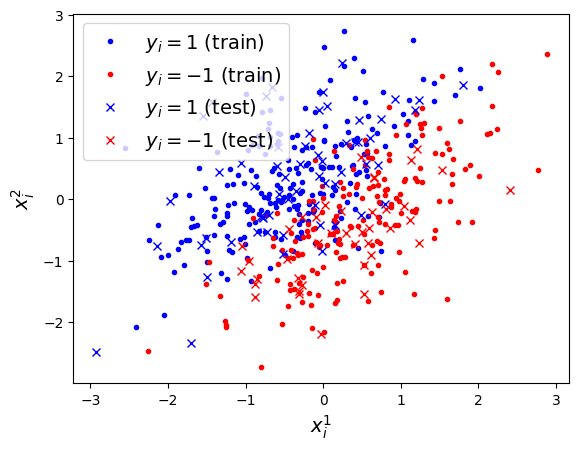

In [10]:
fig, ax = plt.subplots()
ax.plot(*X_train[y_train == 1].T, ".b", label=r"$y_i=1$ (train)")
ax.plot(*X_train[y_train == -1].T, ".r", label=r"$y_i=-1$ (train)")
ax.plot(*X_test[y_test == 1].T, "bx", label=r"$y_i=1$ (test)")
ax.plot(*X_test[y_test == -1].T, "rx", label=r"$y_i=-1$ (test)")
ax.set_xlabel(r"$x_i^1$")
ax.set_ylabel(r"$x_i^2$")
ax.legend(loc="upper left")
plt.show()

In [11]:
# fit a logistic regression model on the training set
logreg_clf = LogisticRegression()
logreg_clf.fit(X_train, y_train)

LogisticRegression()

In [12]:
# show the regeression coefficients
print("Coefficients:", logreg_clf.coef_)
print("Intercept:", logreg_clf.intercept_)

Coefficients: [[-2.69671732  2.30957157]]
Intercept: [0.25276384]


In [13]:
y_pred = logreg_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=[1, -1])
TP, FN = cm[0, 0], cm[0, 1]
FP, TN = cm[1, 0], cm[1, 1]

print("Confusion matrix (labels=[1,-1]):\n", cm)
print(f"TP={TP}, FN={FN}, FP={FP}, TN={TN}")


Confusion matrix (labels=[1,-1]):
 [[51  9]
 [ 6 34]]
TP=51, FN=9, FP=6, TN=34


In [14]:
# Accuracy on the test set
test_acc = (TP + TN) / np.sum(cm)
print(f"Test set accuracy: {test_acc:.4f}")

Test set accuracy: 0.8500


In [15]:
# another direct way with the score method
test_acc_direct = logreg_clf.score(X_test, y_test)
print(f"Test set accuracy (direct): {test_acc_direct:.4f}")

Test set accuracy (direct): 0.8500


In [16]:
# other metrics
from sklearn.metrics import confusion_matrix, classification_report

y_pred = logreg_clf.predict(X_test)
confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.79      0.85      0.82        40
           1       0.89      0.85      0.87        60

    accuracy                           0.85       100
   macro avg       0.84      0.85      0.85       100
weighted avg       0.85      0.85      0.85       100



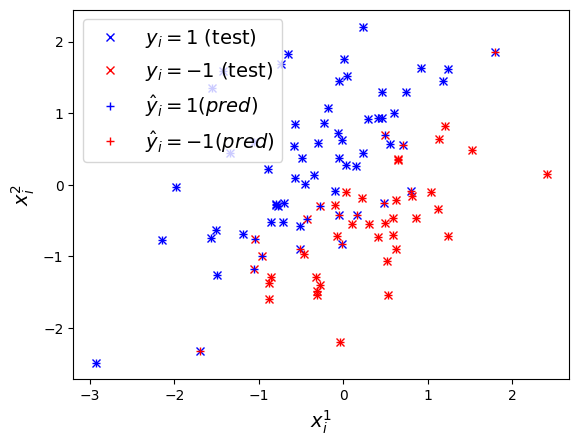

In [17]:
fig, ax = plt.subplots()
ax.plot(*X_test[y_test == 1].T, "bx", label=r"$y_i=1$ (test)")
ax.plot(*X_test[y_test == -1].T, "rx", label=r"$y_i=-1$ (test)")
ax.plot(*X_test[logreg_clf.predict(X_test) == 1].T, "b+", label=r"$\hat{y}_i=1 (pred)$")
ax.plot(
    *X_test[logreg_clf.predict(X_test) == -1].T, "r+", label=r"$\hat{y}_i=-1 (pred)$"
)
ax.set_xlabel(r"$x_i^1$")
ax.set_ylabel(r"$x_i^2$")
ax.legend(loc="upper left")
plt.show()

In [18]:
# dummy classifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train)

DummyClassifier()

In [19]:
# most frequent is +1, so it predicts all samples as 1
print(X_train[y_train == 1].shape[0] / X_train.shape[0])
print(X_train[y_train == -1].shape[0] / X_train.shape[0])

0.545
0.455


In [20]:
# dummy classifier
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42).fit(X_train, y_train)
y_pred = dummy_clf.predict(X_test)

In [21]:
# Evaluate the accuracy of the logistic regression classifier using k-fold
# cross-validation
k = 10
cv_scores = cross_val_score(logreg_clf, X_train, y_train, cv=k)
print(f"{k}-fold cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")

10-fold cross-validation scores: [0.925 0.8   0.875 0.875 0.85  0.8   0.85  0.8   0.8   0.8  ]
Mean CV accuracy: 0.8375


In [22]:
# confusion matrix - we do not use the test set, but we use cross-validation to
# get predictions for the training set

y_train_pred = cross_val_predict(logreg_clf, X_train, y_train, cv=3)

In [23]:
cm = confusion_matrix(y_train, y_train_pred)
print(cm)

[[146  36]
 [ 32 186]]


In [24]:
# confusion matrix layout:
# [[TN, FP],
#  [FN, TP]]

# true negative = TN
print("True Negatives:", cm[0, 0])

# false positives = FP
print("False Positives:", cm[1, 0])

# false negatives = FN
print("False Negatives:", cm[0, 1])

# true positives = TP
print("True Positives:", cm[1, 1])

True Negatives: 146
False Positives: 32
False Negatives: 36
True Positives: 186


In [25]:
# accuracy of the positive predictions = the precision of the classifier
# TP / (FP + TP)

print("Precision:", precision_score(y_train, y_train_pred))

Precision: 0.8378378378378378


In [26]:
# another metric: recall = TP / (FN + TP)
print("Recall:", recall_score(y_train, y_train_pred))

Recall: 0.8532110091743119


# MNIST

In [27]:
mnist = fetch_openml("mnist_784", as_frame=False)

/Users/junshao/anaconda3/envs/fe-course/lib/python3.11/site-packages/sklearn/datasets/_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [28]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [29]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [30]:
# let us look at the mnist data
X, y = mnist.data, mnist.target
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [31]:
print("X.shape:", X.shape)

X.shape: (70000, 784)


In [32]:
print(y)

['5' '0' '4' ... '4' '5' '6']


In [33]:
print("y.shape:", y.shape)

y.shape: (70000,)


In [34]:
28 * 28

784

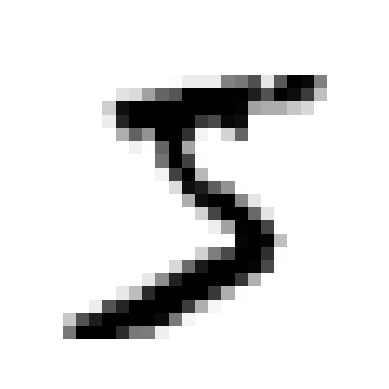

In [35]:
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
    plt.show()


# plot digit with index idx
idx = 0
plot_digit(X[idx])

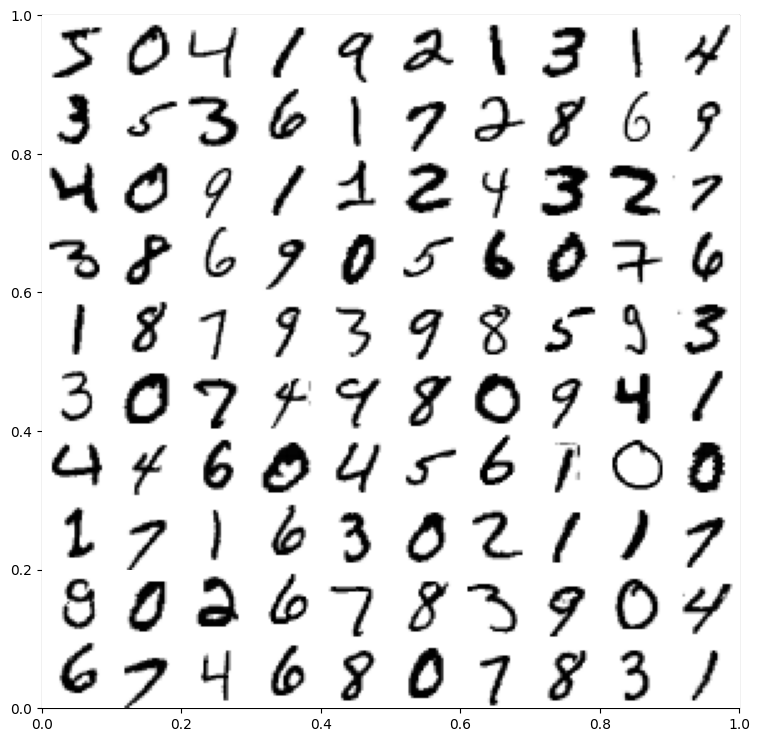

In [36]:
fig, ax = plt.subplots(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
plt.subplots_adjust(wspace=0, hspace=0)

In [37]:
# split the data into a training set and a test set
# it is randomly shuffled, so we can just take the first 60000 samples as the training
# set and the last 10000 samples as the test set
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# Training a Binary Classifier

In [38]:
y_train_5 = y_train == "5"  # True for all 5s, False for all other digits
y_test_5 = y_test == "5"  # True for all 5s, False for all other digits

In [39]:
from sklearn.linear_model import SGDClassifier

# look at the SGD classifier, which is a linear classifier that can be used for
# large datasets
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [40]:
some_digit = X[36000]
sgd_clf.predict([some_digit])

array([False])

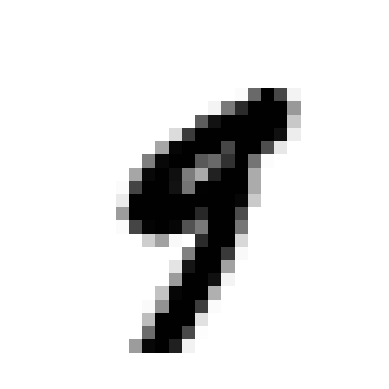

In [41]:
plot_digit(some_digit)

# Performance Measures

## Measuring Accuracy Using Cross-Validation

In [ ]:
# cross-validation with the SGD classifier and cv=3
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
cm = confusion_matrix(y_train_5, y_train_pred)
print(cm)

[[53892   687]
 [ 1891  3530]]


In [43]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3)  # add shuffle=True if the dataset is
# not already shuffled
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.95035
0.96035
0.9604


In [44]:
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


In [45]:
# cross-validation with the SGD classifier and cv=3
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
cm = confusion_matrix(y_train_5, y_train_pred)
print(cm)

[[53892   687]
 [ 1891  3530]]


- The dummy classifier has over 90% accuracy.

- This is because the dataset is imbalanced, with 90% of the samples belonging to one class and only 10% belonging to the other class.

- Accuracy is not a good measure of performance in this case, as it can be misleading. A better measure of performance would be precision, recall, or the F1 score, which take into account the imbalance in the dataset.

## Confusion Matrix

In [47]:
# confusion matrix - we do not use the test set, but we use cross-validation
# to get predictions for the training set
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [49]:
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In [50]:
print(f"TP: {cm[1, 1]}, FP: {cm[0, 1]}, TN: {cm[0, 0]}, FN: {cm[1, 0]}")

TP: 3530, FP: 687, TN: 53892, FN: 1891


In [51]:
y_train_perfect_predictions = y_train_5  # pretend we reached perfection
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

## Precision and Recall

In [52]:
precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [53]:
# TP / (FP + TP)
cm[1, 1] / (cm[0, 1] + cm[1, 1])

0.8370879772350012

In [54]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

In [55]:
# TP / (FN + TP)
cm[1, 1] / (cm[1, 0] + cm[1, 1])

0.6511713705958311

In [56]:
# the F1 score is the harmonic mean of precision and recall
f1_score(y_train_5, y_train_pred)

0.7325171197343846

In [57]:
# f1 score
1 / (
    0.5 / precision_score(y_train_5, y_train_pred)
    + 0.5 / recall_score(y_train_5, y_train_pred)
)

0.7325171197343847

<img src="figures/confusion_matrix_mnist.png" width="800">

## Precision/Recall Trade-off

In [58]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([-3491.23647576])

In [59]:
threshold = 0
y_some_digit_pred = y_scores > threshold

In [60]:
y_some_digit_pred

array([False])

In [61]:
# extra code – just shows that y_scores > 0 produces the same result as
#              calling predict()
y_scores > 0

array([False])

In [62]:
threshold = 3000
y_some_digit_pred = y_scores > threshold
y_some_digit_pred

array([False])

In [63]:
y_scores = cross_val_predict(
    sgd_clf, X_train, y_train_5, cv=3, method="decision_function"
)

In [64]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

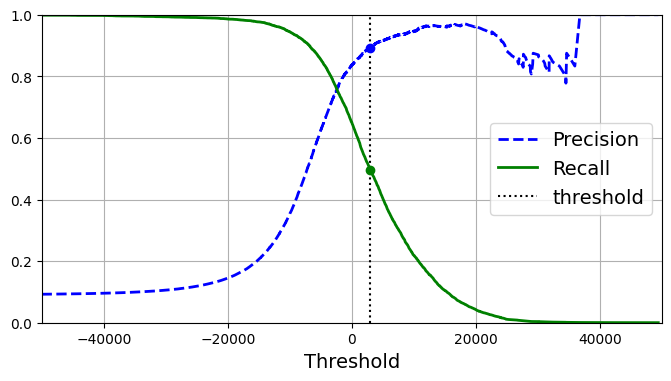

In [65]:
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")

plt.show()

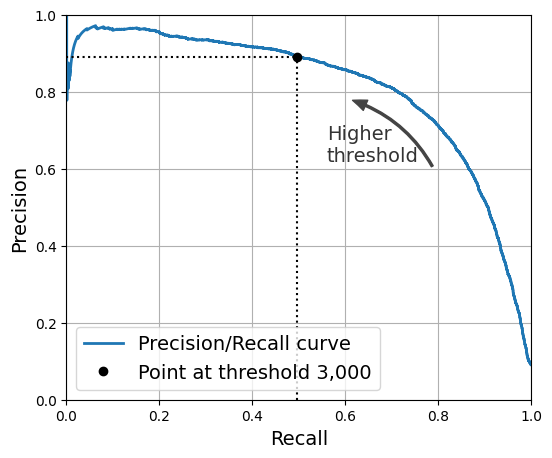

In [66]:
import matplotlib.patches as patches  # extra code – for the curved arrow

plt.figure(figsize=(6, 5))

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# extra code – just beautifies Figure 3–6
plt.plot([recalls[idx], recalls[idx]], [0.0, precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko", label="Point at threshold 3,000")
plt.gca().add_patch(
    patches.FancyArrowPatch(
        (0.79, 0.60),
        (0.61, 0.78),
        connectionstyle="arc3,rad=.2",
        arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
        color="#444444",
    )
)
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")

plt.show()

In [67]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

3370.0194991439566

In [68]:
y_train_pred_90 = y_scores >= threshold_for_90_precision

In [69]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [70]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

## The ROC Curve

In [71]:
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

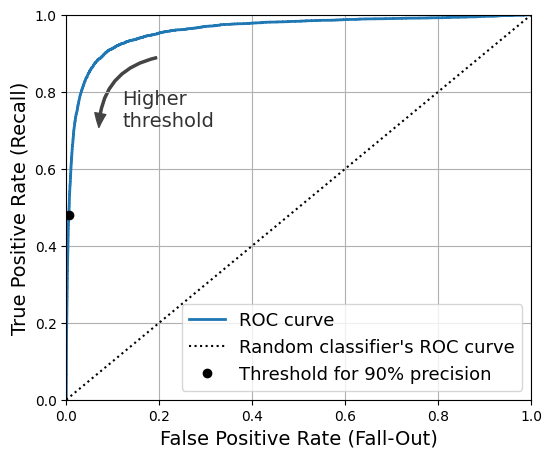

In [72]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], "k:", label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

plt.gca().add_patch(
    patches.FancyArrowPatch(
        (0.20, 0.89),
        (0.07, 0.70),
        connectionstyle="arc3,rad=.4",
        arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
        color="#444444",
    )
)
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel("False Positive Rate (Fall-Out)")
plt.ylabel("True Positive Rate (Recall)")
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)

plt.show()

In [73]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

0.9604938554008616